# Factores de Certidumbre Cuántico

Una vez definido el modelo de factores de certidumbre clásico, pasamos a ver cómo imlpementar cada uno de los elementos mediante Computación Cuántica.

In [1]:
import pennylane as qml
import numpy as np

## Evidencias $e$

Para modelar las evidencias, se hace uso de qubits singulares, los cuales se inicializan de acuerdo a su $CF \in [-1,1]$ mediante operaciones de rotación, para las que usaremos el operador paramétrico $R_Y(\theta)$:

$$CF(e_n,\varepsilon_n) \equiv e \Rightarrow R_Y\left(arcsin(e) + \frac{\pi}{2}\right)$$


In [2]:
def quantum_cf(cf, wire):
    qml.RY(np.arcsin(cf) + np.pi/2, wire)

In [3]:
dev = qml.device("default.qubit", wires = 1)

@qml.qnode(dev)
def quantum_cf_example(cf):
    quantum_cf(cf, 0)
    return qml.state()

for x in np.linspace(-1,1,21):
    print(f"{x:.1f}", quantum_cf_example(x))

-1.0 [1.+0.j 0.+0.j]
-0.9 [0.97467943+0.j 0.2236068 +0.j]
-0.8 [0.9486833 +0.j 0.31622777+0.j]
-0.7 [0.92195445+0.j 0.38729833+0.j]
-0.6 [0.89442719+0.j 0.4472136 +0.j]
-0.5 [0.8660254+0.j 0.5      +0.j]
-0.4 [0.83666003+0.j 0.54772256+0.j]
-0.3 [0.80622577+0.j 0.59160798+0.j]
-0.2 [0.77459667+0.j 0.63245553+0.j]
-0.1 [0.74161985+0.j 0.67082039+0.j]
0.0 [0.70710678+0.j 0.70710678+0.j]
0.1 [0.67082039+0.j 0.74161985+0.j]
0.2 [0.63245553+0.j 0.77459667+0.j]
0.3 [0.59160798+0.j 0.80622577+0.j]
0.4 [0.54772256+0.j 0.83666003+0.j]
0.5 [0.5      +0.j 0.8660254+0.j]
0.6 [0.4472136 +0.j 0.89442719+0.j]
0.7 [0.38729833+0.j 0.92195445+0.j]
0.8 [0.31622777+0.j 0.9486833 +0.j]
0.9 [0.2236068 +0.j 0.97467943+0.j]
1.0 [6.123234e-17+0.j 1.000000e+00+0.j]


## Operadores cuánticos lógicos

Para implementar los operadores cuánticos lógicos $AND$ y $OR$, se aplican los siguientes operadores cuánticos:

### Operador cuántico $AND$

Se implementa mediante un operador $MCX$ controlado por los qubits de las evidencias que se quieren agrupar y actuando sobre el qubit que representará el resultado de la operación:

$$QAND(A,B) \equiv MCX(\ket{A}\otimes\ket{B},\ket{0}) = \ket{A}\otimes\ket{B},\ket{A \land B}$$

#### Ejercicio 1

Implementa el operador cuántico lógico $AND$ para dos evidencias.

In [4]:
def quantum_and(a, b, target):
    qml.Toffoli(wires=[a, b, target])

In [5]:
dev = qml.device("default.qubit", wires=3, shots=1)  # redefine according to your needs


@qml.qnode(dev)
def quantum_and_example(a: bool, b: bool):
    if a:
        qml.PauliX(wires=0)
    if b:
        qml.PauliX(wires=1)

    quantum_and(0, 1, 2)

    return qml.sample(wires=[2])


# define a loop to test the operator with multiple inputs
inputs = (
    {"a": False, "b": False},
    {"a": False, "b": True},
    {"a": True, "b": False},
    {"a": True, "b": True},
)

for input in inputs:
    result = quantum_and_example(input["a"], input["b"])
    result_str = "Verdadero" if result[0] else "Falso"
    print(f"Resultado tras la medición '{result_str}'")

Resultado tras la medición 'Falso'
Resultado tras la medición 'Falso'
Resultado tras la medición 'Falso'
Resultado tras la medición 'Verdadero'


/home/esteban/anaconda3/envs/sbr/lib/python3.12/site-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


### Operador cuántico $OR$

Se implementa mediante un operador $MCX$ controlado por los qubits **negados** de las evidencias que se quieren agrupar y actuando sobre el qubit **negado** que representará el resultado de la operación:

$$QOR(A,B) \equiv (X^{\otimes^3}) MCX (X^{\otimes^2} \otimes I) (\ket{A}\otimes\ket{B},\ket{0}) = \ket{A}\otimes\ket{B},\ket{A \lor B}$$

#### Ejercicio 2

Implementa el operador cuántico lógico $OR$ para dos evidencias.


In [6]:
def quantum_or(a, b, target):
    qml.PauliX(wires=a)
    qml.PauliX(wires=b)
    qml.Toffoli(wires=[a, b, target])
    qml.PauliX(wires=a)
    qml.PauliX(wires=b)
    qml.PauliX(wires=target)

In [7]:
dev = qml.device("default.qubit", wires=3, shots=1)  # redefine according to your needs


@qml.qnode(dev)
def quantum_or_example(a: bool, b: bool):
    if a:
        qml.PauliX(wires=0)
    if b:
        qml.PauliX(wires=1)

    quantum_or(0, 1, 2)

    return qml.sample(wires=[2])


# define a loop to test the operator with multiple inputs
inputs = (
    {"a": False, "b": False},
    {"a": False, "b": True},
    {"a": True, "b": False},
    {"a": True, "b": True},
)

for input in inputs:
    result = quantum_or_example(input["a"], input["b"])
    result_str = "Verdadero" if result[0] else "Falso"
    print(f"Resultado tras la medición '{result_str}'")

Resultado tras la medición 'Falso'
Resultado tras la medición 'Verdadero'
Resultado tras la medición 'Verdadero'
Resultado tras la medición 'Verdadero'


### Definición de reglas

Una vez se haya construido el precedente de la regla mediante las combinaciones de evidencias a través de los operadores lógicos, se implementa la regla mediante un operador Toffoli, que utiliza como control el qubit que representa el precedente y otro qubit que representa la incertidumbre de la regla para actuar en el qubit que representa el consecuente:

$$QRULE(PRE,RULE) \equiv MCX(\ket{PRE}\otimes\ket{RULE},\ket{0}) = \ket{PRE}\otimes\ket{RULE},\ket{CON}$$

#### Ejercicio 3

Implementa el operador cuántico para las reglas.

In [8]:
def quantum_rule(pre, rule, con):
    qml.Toffoli(wires=[pre, rule, con])

In [9]:
dev = qml.device("default.qubit", wires=3, shots=1)


@qml.qnode(dev)
def quantum_rule_example(pre: bool, rule: bool):
    # Prepare precedent (pre) on wire 0 and rule uncertainty on wire 1
    if pre:
        qml.PauliX(wires=0)
    if rule:
        qml.PauliX(wires=1)

    # Apply the rule (Toffoli): PRE & RULE -> consequent (wire 2)
    quantum_rule(0, 1, 2)

    # Return the measured value of the consequent qubit
    return qml.sample(wires=[2])


# define a loop to test the operator with multiple inputs
inputs = (
    {"pre": False, "rule": False},
    {"pre": False, "rule": True},
    {"pre": True, "rule": False},
    {"pre": True, "rule": True},
)

for input in inputs:
    result = quantum_rule_example(input["pre"], input["rule"])
    result_str = "Verdadero" if result[0] else "Falso"
    print(f"Resultado tras la medición '{result_str}'")

Resultado tras la medición 'Falso'
Resultado tras la medición 'Falso'
Resultado tras la medición 'Falso'
Resultado tras la medición 'Verdadero'


### Composición del sistema

Con los elementos definidos, se puede componer un sistema complejo basado en reglas. Para ponerlo en práctica, implementaremos el siguiente conjunto de reglas:

$R1: \text{ IF } \mathcal{A}\ AND\ \mathcal{B} \text{ THEN } \mathcal{X}$

$R2: \text{ IF } \mathcal{X}\ OR\ \mathcal{C} \text{ THEN } \mathcal{Y}$

$R1: \text{ IF } (\mathcal{D}\ OR\ \mathcal{E})\ AND\ \mathcal{Y} \text{ THEN } \mathcal{H}$

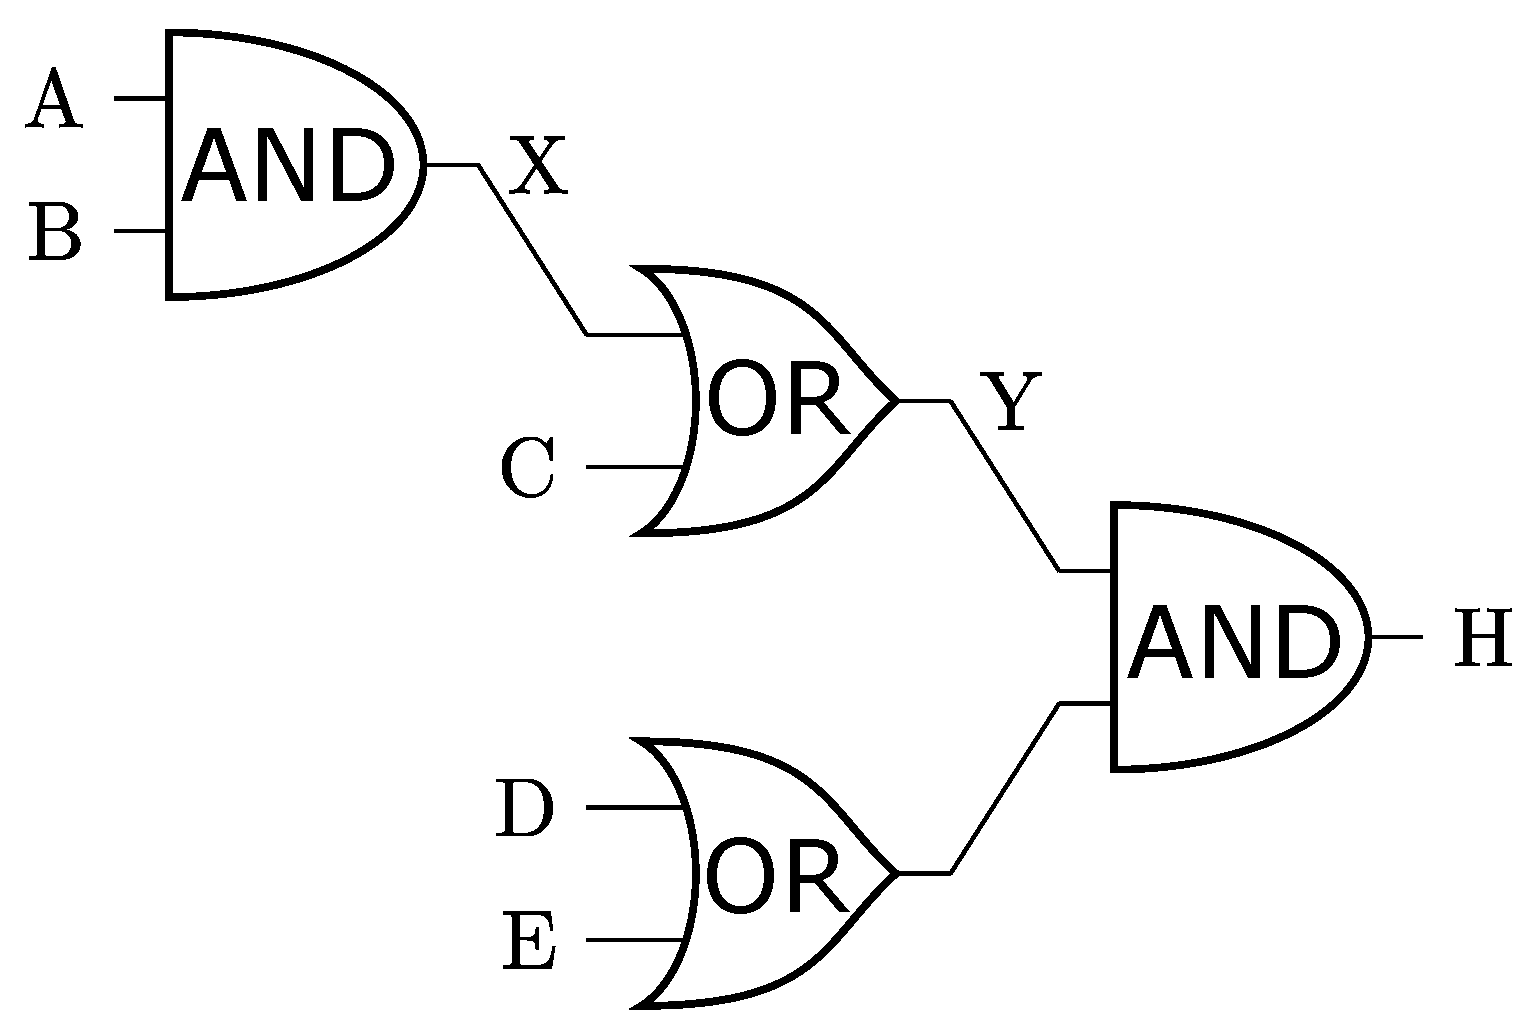

#### Ejercicio 4

Implementa el circuito cuántico para el sistema.

In [10]:
dev = qml.device(
    "default.qubit",
    wires=[ #definimos los cubits con los nombres de las variables para que sea mas legible
        "a",
        "b",
        "c",
        "d",
        "e",
        "x",
        "y",
        "z",
        "h",
        "a_AND_b",
        "x_OR_c",
        "d_OR_e",
        "y_AND_(d_OR_e)",
        "r1",
        "r2",
        "r3",
    ],
    shots=1,
 )

@qml.qnode(dev)
def sistema_quantico(
    a: bool,
    b: bool,
    c: bool,
    d: bool,
    e: bool,
 ):
    if a:
        qml.PauliX(wires="a")
    if b:
        qml.PauliX(wires="b")
    if c:
        qml.PauliX(wires="c")
    if d:
        qml.PauliX(wires="d")
    if e:
        qml.PauliX(wires="e")

    qml.PauliX(wires="r1")
    qml.PauliX(wires="r2")
    qml.PauliX(wires="r3")

    # R1: IF A AND B THEN X
    quantum_and("a", "b", "a_AND_b")
    quantum_rule("a_AND_b", "r1", "x")

    # R2: IF X OR C THEN Y
    quantum_or("x", "c", "x_OR_c")
    quantum_rule("x_OR_c", "r2", "y")

    # R3: IF (D OR E) AND Y THEN H
    quantum_or("d", "e", "d_OR_e")
    quantum_and("d_OR_e", "y", "y_AND_(d_OR_e)")
    quantum_rule("y_AND_(d_OR_e)", "r3", "h")

    # devolvemos los consecuentes
    return qml.sample(wires=["x", "y", "h"])

def sistema_clasico(a: bool, b: bool, c: bool, d: bool, e: bool):
    x = a and b
    y = x or c
    h = (d or e) and y
    return int(x), int(y), int(h)

inputs = [
    {"a": False, "b": False, "c": False, "d": False, "e": False},
    {"a": True, "b": True, "c": False, "d": False, "e": False},
    {"a": False, "b": False, "c": True, "d": False, "e": False},
    {"a": True, "b": True, "c": False, "d": True, "e": False},
    {"a": False, "b": False, "c": False, "d": True, "e": True},
 ]

for input in inputs:
    results = sistema_quantico(input["a"], input["b"], input["c"], input["d"], input["e"])
    results = np.squeeze(results)
    x, y, h = int(results[0]), int(results[1]), int(results[2])
    cx, cy, ch = sistema_clasico(input["a"], input["b"], input["c"], input["d"], input["e"])
    ok = (x, y, h) == (cx, cy, ch)
    print(
        f"Entradas A={input['a']} B={input['b']} C={input['c']} D={input['d']} E={input['e']} -> X={x} Y={y} H={h} | clasico=({cx},{cy},{ch}) ok={ok}"
    )

Entradas A=False B=False C=False D=False E=False -> X=0 Y=0 H=0 | clasico=(0,0,0) ok=True
Entradas A=True B=True C=False D=False E=False -> X=1 Y=1 H=0 | clasico=(1,1,0) ok=True
Entradas A=False B=False C=True D=False E=False -> X=0 Y=1 H=0 | clasico=(0,1,0) ok=True
Entradas A=True B=True C=False D=True E=False -> X=1 Y=1 H=1 | clasico=(1,1,1) ok=True
Entradas A=False B=False C=False D=True E=True -> X=0 Y=0 H=0 | clasico=(0,0,0) ok=True
